# REGRESSION — TASK 1: Dataset Understanding + EDA (COVID Hospital Capacity Dataset)
In this task, we:

Load the COVID timeseries dataset and inspect structure.

Identify a suitable numeric target variable for regression.

Check data quality (missing values, duplicates, data types).

Perform EDA with simple, report-friendly plots.

Prepare report notes: UNSDG link + questions the dataset can answer.

In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv("COVID-19_Reported_Patient_Impact_and_Hospital_Capacity_by_State_Timeseries__RAW_.csv")

print("SHAPE (rows, cols):", df.shape)
print("\nFIRST 5 ROWS:")
display(df.head())

print("\nINFO:")
df.info()

print("\nMISSING VALUES (TOP 20):")
display(df.isna().sum().sort_values(ascending=False).head(20))

print("\nDUPLICATE ROWS:", df.duplicated().sum())


SHAPE (rows, cols): (81713, 135)

FIRST 5 ROWS:


,state,date,critical_staffing_shortage_today_yes,critical_staffing_shortage_today_no,critical_staffing_shortage_today_not_reported,critical_staffing_shortage_anticipated_within_week_yes,critical_staffing_shortage_anticipated_within_week_no,critical_staffing_shortage_anticipated_within_week_not_reported,hospital_onset_covid,hospital_onset_covid_coverage,...,previous_day_admission_pediatric_covid_confirmed_5_11,previous_day_admission_pediatric_covid_confirmed_5_11_coverage,previous_day_admission_pediatric_covid_confirmed_unknown,previous_day_admission_pediatric_covid_confirmed_unknown_coverage,staffed_icu_pediatric_patients_confirmed_covid,staffed_icu_pediatric_patients_confirmed_covid_coverage,staffed_pediatric_icu_bed_occupancy,staffed_pediatric_icu_bed_occupancy_coverage,total_staffed_pediatric_icu_beds,total_staffed_pediatric_icu_beds_coverage
0,AR,2021/06/12,13,96,2,16,93,2,1.0,109,...,NaN,0,NaN,0,NaN,0,284.0,109,423.0,109
1,IA,2021/05/19,1,65,60,1,65,60,0.0,124,...,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0
2,RI,2021/03/30,3,11,1,3,11,1,7.0,14,...,NaN,0,NaN,0,NaN,0,77.0,14,96.0,14
3,RI,2021/03/29,3,11,1,3,11,1,7.0,14,...,NaN,0,NaN,0,NaN,0,73.0,14,96.0,14
4,MS,2020/05/23,0,0,80,0,0,80,4.0,77,...,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0



INFO:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 81713 entries, 0 to 81712
Columns: 135 entries, state to total_staffed_pediatric_icu_beds_coverage
dtypes: float64(77), int64(56), object(2)
memory usage: 84.2+ MB

MISSING VALUES (TOP 20):


,0
geocoded_state,81713
previous_day_admission_pediatric_covid_confirmed_12_17,37049
previous_day_admission_pediatric_covid_confirmed_5_11,37036
previous_day_admission_pediatric_covid_confirmed_0_4,36412
previous_day_admission_pediatric_covid_confirmed_unknown,36296
staffed_icu_pediatric_patients_confirmed_covid,30149
on_hand_supply_therapeutic_c_bamlanivimab_etesevimab_courses,22857
previous_week_therapeutic_c_bamlanivimab_etesevimab_courses_used,22800
on_hand_supply_therapeutic_b_bamlanivimab_courses,20281
previous_week_therapeutic_b_bamlanivimab_courses_used,20208



DUPLICATE ROWS: 0


## TASK 1 — Code Cell 2: Parse date + quick column cleanup

In [3]:
df.columns = [c.strip() for c in df.columns]

#Common date column in this dataset is usually "date"
if "date" in df.columns:
    df["date"] = pd.to_datetime(df["date"], errors="coerce")
    print("Parsed 'date' as datetime. NaT count:", df["date"].isna().sum())
else:
    #If date column name differs, try to detect
    possible_date_cols = [c for c in df.columns if "date" in c.lower() or "time" in c.lower()]
    print("No 'date' column found. Possible date columns:", possible_date_cols)

print("COLUMNS COUNT:", len(df.columns))


Parsed 'date' as datetime. NaT count: 0
COLUMNS COUNT: 135


## TASK 1 — Code Cell 3: Choose a regression target

In [4]:
candidate_targets = [
    "inpatient_beds_used_covid",
    "previous_day_admission_adult_covid_confirmed",
    "previous_day_admission_pediatric_covid_confirmed",
    "inpatient_beds_used",
    "adult_icu_bed_utilization",
    "staffed_adult_icu_bed_occupancy",
]

target_col = None
for c in candidate_targets:
    if c in df.columns:
        target_col = c
        break

print("SELECTED TARGET:", target_col)

if target_col is None:
    print("\nNo candidate target found in dataset. Here are numeric columns you can choose from:")
    numeric_cols = df.select_dtypes(include=["number"]).columns.tolist()
    display(numeric_cols[:50])
else:
    print("\nTarget summary:")
    display(df[target_col].describe())
    print("\nMissing values in target:", df[target_col].isna().sum())


SELECTED TARGET: inpatient_beds_used_covid

Target summary:


,inpatient_beds_used_covid
count,80867.000000
mean,766.856530
std,1478.594113
min,0.000000
25%,78.000000
50%,282.000000
75%,823.000000
max,30334.000000



Missing values in target: 846


## TASK 1 — Code Cell 4: Quick EDA plots

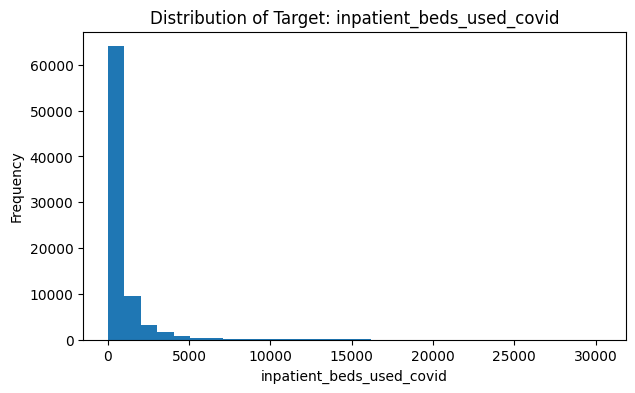

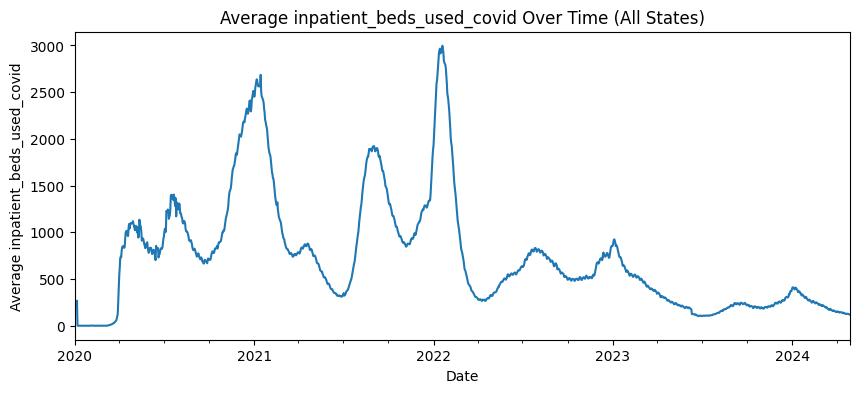

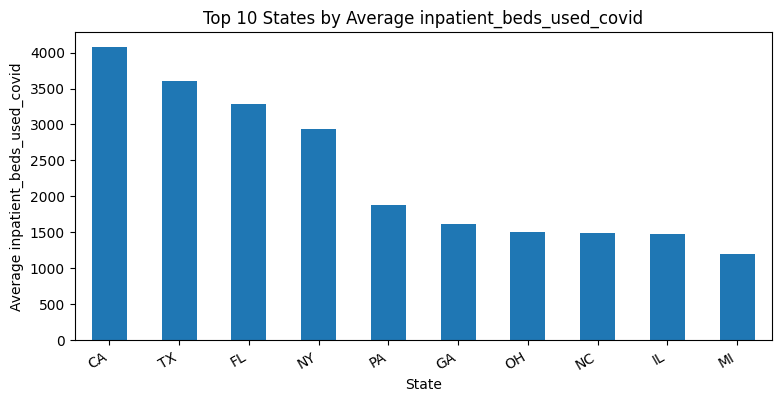

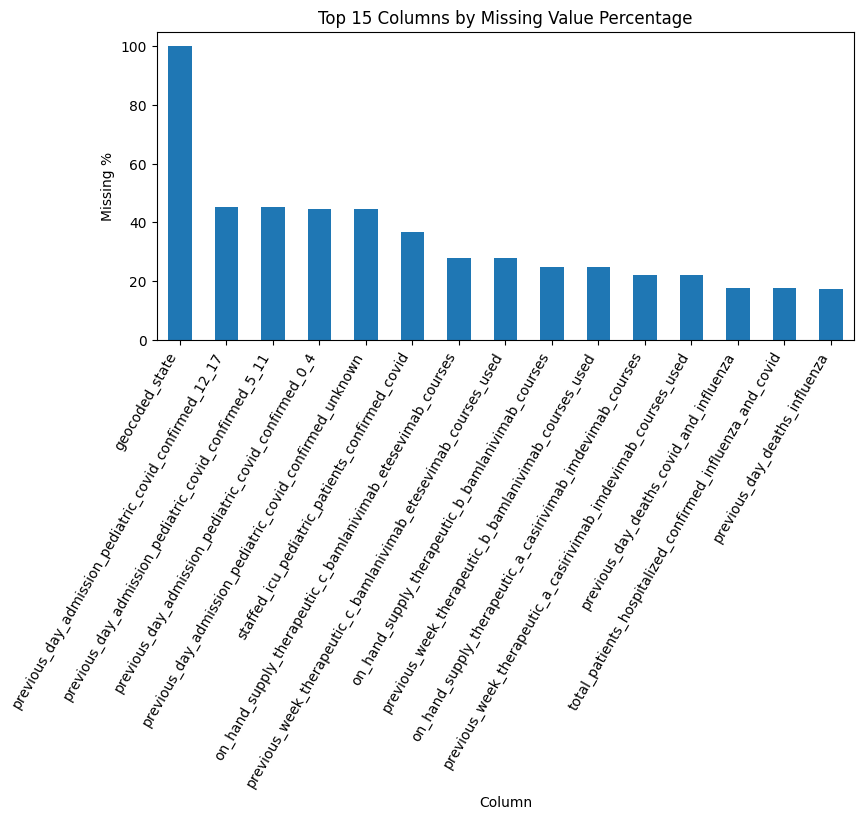

In [5]:
import matplotlib.pyplot as plt

if target_col is not None:
    # 1) Target distribution
    plt.figure(figsize=(7,4))
    df[target_col].dropna().plot(kind="hist", bins=30)
    plt.title(f"Distribution of Target: {target_col}")
    plt.xlabel(target_col)
    plt.ylabel("Frequency")
    plt.show()

    # 2) Target over time (overall average)
    if "date" in df.columns:
        tmp = df.dropna(subset=["date", target_col]).copy()
        daily = tmp.groupby("date")[target_col].mean()

        plt.figure(figsize=(10,4))
        daily.plot()
        plt.title(f"Average {target_col} Over Time (All States)")
        plt.xlabel("Date")
        plt.ylabel(f"Average {target_col}")
        plt.show()

    # 3) Top states by average target (if state column exists)
    state_col = None
    for c in ["state", "State", "state_abbr"]:
        if c in df.columns:
            state_col = c
            break

    if state_col is not None:
        tmp2 = df.dropna(subset=[state_col, target_col]).copy()
        top_states = tmp2.groupby(state_col)[target_col].mean().sort_values(ascending=False).head(10)

        plt.figure(figsize=(9,4))
        top_states.plot(kind="bar")
        plt.title(f"Top 10 States by Average {target_col}")
        plt.xlabel("State")
        plt.ylabel(f"Average {target_col}")
        plt.xticks(rotation=30, ha="right")
        plt.show()

    # 4) Missingness % for top columns
    missing_pct = (df.isna().mean() * 100).sort_values(ascending=False).head(15)
    plt.figure(figsize=(9,4))
    missing_pct.plot(kind="bar")
    plt.title("Top 15 Columns by Missing Value Percentage")
    plt.xlabel("Column")
    plt.ylabel("Missing %")
    plt.xticks(rotation=60, ha="right")
    plt.show()


## REGRESSION — TASK 2: Neural Network Model (MLPRegressor)
In this task, we:

- Select a numeric target variable for regression.

- Prepare features (handle missing values, encode categories, scale numeric values).

- Split data into train/test to measure generalization.

- Train a Neural Network regressor (MLPRegressor).

- Evaluate using MAE, RMSE, and R² on the test set.

In [6]:
import pandas as pd
import numpy as np

df = pd.read_csv("COVID-19_Reported_Patient_Impact_and_Hospital_Capacity_by_State_Timeseries__RAW_.csv")
df.columns = [c.strip() for c in df.columns]

# Parse date if present
if "date" in df.columns:
    df["date"] = pd.to_datetime(df["date"], errors="coerce")

# Choose target (same candidates as Task 1)
candidate_targets = [
    "inpatient_beds_used_covid",
    "previous_day_admission_adult_covid_confirmed",
    "previous_day_admission_pediatric_covid_confirmed",
    "inpatient_beds_used",
    "adult_icu_bed_utilization",
    "staffed_adult_icu_bed_occupancy",
]

target_col = None
for c in candidate_targets:
    if c in df.columns:
        target_col = c
        break

print("SELECTED TARGET:", target_col)

# Drop rows with missing target
df = df.dropna(subset=[target_col])

# Features and target
X = df.drop(columns=[target_col])
y = df[target_col].astype(float)

print("Final dataset shape after dropping missing target:", df.shape)
print("Target describe:")
display(y.describe())


SELECTED TARGET: inpatient_beds_used_covid
Final dataset shape after dropping missing target: (80867, 135)
Target describe:


,inpatient_beds_used_covid
count,80867.000000
mean,766.856530
std,1478.594113
min,0.000000
25%,78.000000
50%,282.000000
75%,823.000000
max,30334.000000


## TASK 2 — Code Cell 2: Train/test split + preprocessing pipeline

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# Identify numeric/categorical feature columns
numeric_features = X.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print("Numeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Preprocessing
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ],
    remainder="drop"
)

print("Train size:", X_train.shape, "Test size:", X_test.shape)


Numeric features: 132
Categorical features: 1
Train size: (64693, 134) Test size: (16174, 134)


## TASK 2 — Code Cell 3: Train MLPRegressor + evaluate

In [8]:
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

nn_model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", MLPRegressor(
        hidden_layer_sizes=(64, 32),
        activation="relu",
        solver="adam",
        max_iter=300,
        random_state=42
    ))
])

nn_model.fit(X_train, y_train)
pred_nn = nn_model.predict(X_test)

mae = mean_absolute_error(y_test, pred_nn)
rmse = np.sqrt(mean_squared_error(y_test, pred_nn))
r2 = r2_score(y_test, pred_nn)

print("NEURAL NETWORK (MLPRegressor)")
print("MAE :", round(mae, 4))
print("RMSE:", round(rmse, 4))
print("R^2 :", round(r2, 4))


/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['geocoded_state']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


NEURAL NETWORK (MLPRegressor)
MAE : 8.7099
RMSE: 52.9578
R^2 : 0.9988


/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['geocoded_state']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


## TASK 3 — Code Cell 1: Load + target + preprocessing + split

In [9]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

df = pd.read_csv("COVID-19_Reported_Patient_Impact_and_Hospital_Capacity_by_State_Timeseries__RAW_.csv")
df.columns = [c.strip() for c in df.columns]

if "date" in df.columns:
    df["date"] = pd.to_datetime(df["date"], errors="coerce")

candidate_targets = [
    "inpatient_beds_used_covid",
    "previous_day_admission_adult_covid_confirmed",
    "previous_day_admission_pediatric_covid_confirmed",
    "inpatient_beds_used",
    "adult_icu_bed_utilization",
    "staffed_adult_icu_bed_occupancy",
]

target_col = None
for c in candidate_targets:
    if c in df.columns:
        target_col = c
        break

print("SELECTED TARGET:", target_col)

df = df.dropna(subset=[target_col])

X = df.drop(columns=[target_col])
y = df[target_col].astype(float)


numeric_features = X.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ],
    remainder="drop"
)

print("Train:", X_train.shape, "Test:", X_test.shape)
print("Numeric:", len(numeric_features), "Categorical:", len(categorical_features))


SELECTED TARGET: inpatient_beds_used_covid
Train: (64693, 134) Test: (16174, 134)
Numeric: 132 Categorical: 1


## TASK 3 — Code Cell 2: Ridge Regression + evaluation

In [10]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

ridge_model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", Ridge(alpha=1.0, random_state=42))
])

ridge_model.fit(X_train, y_train)
pred_ridge = ridge_model.predict(X_test)

mae_ridge = mean_absolute_error(y_test, pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_test, pred_ridge))
r2_ridge = r2_score(y_test, pred_ridge)

print("RIDGE REGRESSION (Test)")
print("MAE :", round(mae_ridge, 4))
print("RMSE:", round(rmse_ridge, 4))
print("R^2 :", round(r2_ridge, 4))


/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['geocoded_state']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


RIDGE REGRESSION (Test)
MAE : 16.6149
RMSE: 68.4418
R^2 : 0.9979


/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['geocoded_state']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


## TASK 3 — Code Cell 3: Random Forest Regressor + evaluation

In [11]:
from sklearn.ensemble import RandomForestRegressor

rf_model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=1
    ))
])

rf_model.fit(X_train, y_train)
pred_rf = rf_model.predict(X_test)

mae_rf = mean_absolute_error(y_test, pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, pred_rf))
r2_rf = r2_score(y_test, pred_rf)

print("RANDOM FOREST REGRESSOR (Test)")
print("MAE :", round(mae_rf, 4))
print("RMSE:", round(rmse_rf, 4))
print("R^2 :", round(r2_rf, 4))


/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['geocoded_state']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['geocoded_state']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


RANDOM FOREST REGRESSOR (Test)
MAE : 5.8635
RMSE: 65.6435
R^2 : 0.9981


## TASK 3 — Code Cell 4: Comparison table (before tuning)

In [12]:
import pandas as pd

results = [
    {"Model": "Ridge (Base)", "MAE": mae_ridge, "RMSE": rmse_ridge, "R^2": r2_ridge},
    {"Model": "Random Forest (Base)", "MAE": mae_rf, "RMSE": rmse_rf, "R^2": r2_rf},
]

comparison_df = pd.DataFrame(results)
display(comparison_df)


,Model,MAE,RMSE,R^2
0,Ridge (Base),16.614931,68.441819,0.997946
1,Random Forest (Base),5.863476,65.643530,0.998111


## REGRESSION — TASK 4: Hyperparameter Tuning with Cross-Validation
In this task, we:

Tune Ridge Regression and Random Forest Regressor using cross-validation.

Use GridSearchCV to find best hyperparameters.

Report the best parameters and best cross-validation score.

Evaluate tuned models on the test set and compare performance.

In [13]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

df = pd.read_csv("COVID-19_Reported_Patient_Impact_and_Hospital_Capacity_by_State_Timeseries__RAW_.csv")
df.columns = [c.strip() for c in df.columns]

if "date" in df.columns:
    df["date"] = pd.to_datetime(df["date"], errors="coerce")

candidate_targets = [
    "inpatient_beds_used_covid",
    "previous_day_admission_adult_covid_confirmed",
    "previous_day_admission_pediatric_covid_confirmed",
    "inpatient_beds_used",
    "adult_icu_bed_utilization",
    "staffed_adult_icu_bed_occupancy",
]

target_col = None
for c in candidate_targets:
    if c in df.columns:
        target_col = c
        break

print("SELECTED TARGET:", target_col)

df = df.dropna(subset=[target_col])

X = df.drop(columns=[target_col])
y = df[target_col].astype(float)

numeric_features = X.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ],
    remainder="drop"
)

# CV (smaller for speed, still valid)
cv = KFold(n_splits=3, shuffle=True, random_state=42)

print("Train:", X_train.shape, "Test:", X_test.shape)
print("CV folds:", cv.get_n_splits())


SELECTED TARGET: inpatient_beds_used_covid
Train: (64693, 134) Test: (16174, 134)
CV folds: 3


## TASK 4 — Code Cell 2: GridSearchCV for Ridge

In [14]:
ridge_pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", Ridge(random_state=42))
])

ridge_params = {
    "model__alpha": [0.1, 1.0, 10.0, 50.0, 100.0]
}

ridge_grid = GridSearchCV(
    estimator=ridge_pipe,
    param_grid=ridge_params,
    cv=cv,
    scoring="neg_root_mean_squared_error",
    n_jobs=1,
    verbose=1
)

ridge_grid.fit(X_train, y_train)

print("BEST Ridge Params:", ridge_grid.best_params_)
print("BEST Ridge CV (neg RMSE):", round(ridge_grid.best_score_, 4))
print("BEST Ridge CV (RMSE):", round(-ridge_grid.best_score_, 4))


Fitting 3 folds for each of 5 candidates, totalling 15 fits


/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['geocoded_state']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['geocoded_state']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['geocoded_state']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['geocoded_state']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/p

BEST Ridge Params: {'model__alpha': 0.1}
BEST Ridge CV (neg RMSE): -67.6006
BEST Ridge CV (RMSE): 67.6006


## TASK 4 — Code Cell 3: GridSearchCV for Random Forest Regressor

In [17]:
import numpy as np
from sklearn.model_selection import RandomizedSearchCV, KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline

# Smaller tuning sample
n_sample = min(8000, len(X_train))   # reduce from 20000 to 8000
X_tune = X_train.sample(n=n_sample, random_state=42)
y_tune = y_train.loc[X_tune.index]

print("Tuning sample size:", X_tune.shape)

rf_pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", RandomForestRegressor(random_state=42))
])

param_dist = {
    "model__n_estimators": [50, 100, 150],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2", None]
}

cv = KFold(n_splits=3, shuffle=True, random_state=42)

rf_rand = RandomizedSearchCV(
    estimator=rf_pipe,
    param_distributions=param_dist,
    n_iter=8,                        # ONLY 8 trials
    cv=cv,
    scoring="neg_root_mean_squared_error",
    n_jobs=1,
    random_state=42,
    verbose=1
)

rf_rand.fit(X_tune, y_tune)

print("BEST RF Params:", rf_rand.best_params_)
print("BEST RF CV (RMSE):", round(-rf_rand.best_score_, 4))

Tuning sample size: (8000, 134)
Fitting 3 folds for each of 8 candidates, totalling 24 fits


/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['geocoded_state']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['geocoded_state']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['geocoded_state']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['geocoded_state']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/p

BEST RF Params: {'model__n_estimators': 100, 'model__min_samples_split': 10, 'model__min_samples_leaf': 2, 'model__max_features': None, 'model__max_depth': 20}
BEST RF CV (RMSE): 129.8219


## TASK 4 — Code Cell 4: Evaluate tuned models on test set + compare

In [22]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

best_rf = rf_rand.best_estimator_   # uses your best params automatically

pred = best_rf.predict(X_test)

mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))
r2 = r2_score(y_test, pred)

if "geocoded_state" in X_train.columns:
    X_train = X_train.drop(columns=["geocoded_state"])
    X_test  = X_test.drop(columns=["geocoded_state"])
    print("Dropped geocoded_state (all missing).")

print("TUNED Random Forest (Test)")
print("MAE :", round(mae, 4))
print("RMSE:", round(rmse, 4))
print("R^2 :", round(r2, 4))


/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['geocoded_state']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


Dropped geocoded_state (all missing).
TUNED Random Forest (Test)
MAE : 16.1224
RMSE: 143.8126
R^2 : 0.9909


## TASK 5: Feature Selection (SelectKBest)
In this task, we:

Apply feature selection to reduce the number of input features.

Use SelectKBest (f_regression) to keep the most relevant features for predicting the target.

Select the best K using cross-validation.

Re-train both tuned models (Ridge and Random Forest) using only the selected features.

Compare performance before vs after feature selection.

In [23]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.impute import SimpleImputer

from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor

df = pd.read_csv("COVID-19_Reported_Patient_Impact_and_Hospital_Capacity_by_State_Timeseries__RAW_.csv")
df.columns = [c.strip() for c in df.columns]

if "date" in df.columns:
    df["date"] = pd.to_datetime(df["date"], errors="coerce")

candidate_targets = [
    "inpatient_beds_used_covid",
    "previous_day_admission_adult_covid_confirmed",
    "previous_day_admission_pediatric_covid_confirmed",
    "inpatient_beds_used",
    "adult_icu_bed_utilization",
    "staffed_adult_icu_bed_occupancy",
]

target_col = None
for c in candidate_targets:
    if c in df.columns:
        target_col = c
        break

print("SELECTED TARGET:", target_col)

df = df.dropna(subset=[target_col])

X = df.drop(columns=[target_col])
y = df[target_col].astype(float)

numeric_features = X.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Preprocess: MinMaxScaler works nicely with feature selection
numeric_transformer_fs = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", MinMaxScaler())
])

categorical_transformer_fs = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess_fs = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_fs, numeric_features),
        ("cat", categorical_transformer_fs, categorical_features)
    ],
    remainder="drop"
)

cv = KFold(n_splits=3, shuffle=True, random_state=42)

print("Train:", X_train.shape, "Test:", X_test.shape)
print("Numeric:", len(numeric_features), "Categorical:", len(categorical_features))


SELECTED TARGET: inpatient_beds_used_covid
Train: (64693, 134) Test: (16174, 134)
Numeric: 132 Categorical: 1


TASK 5 — Code Cell 2: Find best K using CV

In [25]:
k_candidates = [20, 40, 60, 100]  # keep small for speed

k_scores = []
for k in k_candidates:
    pipe = Pipeline(steps=[
        ("preprocess", preprocess_fs),
        ("select", SelectKBest(score_func=f_regression, k=k)),
        ("model", Ridge(alpha=1.0, random_state=42))
    ])

    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="neg_root_mean_squared_error", n_jobs=1)
    mean_score = scores.mean()
    k_scores.append((k, mean_score))
    print(f"K={k} -> CV neg RMSE mean: {mean_score:.4f}  |  RMSE: {-mean_score:.4f}")

if "geocoded_state" in X_train.columns:
    X_train = X_train.drop(columns=["geocoded_state"])
    X_test  = X_test.drop(columns=["geocoded_state"])
    print("Dropped geocoded_state (all missing).")

best_k = sorted(k_scores, key=lambda x: x[1], reverse=True)[0][0]
print("\nBEST K SELECTED:", best_k)


/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['geocoded_state']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['geocoded_state']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['geocoded_state']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['geocoded_state']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/p

K=20 -> CV neg RMSE mean: -106.5516  |  RMSE: 106.5516


/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['geocoded_state']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['geocoded_state']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['geocoded_state']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['geocoded_state']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/p

K=40 -> CV neg RMSE mean: -99.8996  |  RMSE: 99.8996


/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['geocoded_state']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['geocoded_state']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['geocoded_state']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['geocoded_state']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/p

K=60 -> CV neg RMSE mean: -95.9170  |  RMSE: 95.9170


/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['geocoded_state']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['geocoded_state']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['geocoded_state']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['geocoded_state']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/p

K=100 -> CV neg RMSE mean: -89.1428  |  RMSE: 89.1428
Dropped geocoded_state (all missing).

BEST K SELECTED: 100


/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['geocoded_state']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


## TASK 5 — Code Cell 3: Train BOTH models with selected features + evaluate

In [28]:
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.impute import SimpleImputer

from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


for col in ["geocoded_state"]:
    if col in X_train.columns:
        X_train = X_train.drop(columns=[col])
    if col in X_test.columns:
        X_test = X_test.drop(columns=[col])


numeric_features = X_train.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X_train.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print("Numeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))
print("geocoded_state exists?", "geocoded_state" in X_train.columns)



numeric_transformer_fs = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", MinMaxScaler())
])

categorical_transformer_fs = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess_fs = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_fs, numeric_features),
        ("cat", categorical_transformer_fs, categorical_features)
    ],
    remainder="drop"
)



best_alpha = 1.0
if "ridge_grid" in globals() and hasattr(ridge_grid, "best_params_"):
    best_alpha = ridge_grid.best_params_.get("model__alpha", 1.0)

# RF params (prefer rf_rand if you used RandomizedSearchCV)
rf_best = {
    "model__n_estimators": 200,
    "model__max_depth": None,
    "model__min_samples_split": 2,
    "model__min_samples_leaf": 1,
    "model__max_features": "sqrt"
}

if "rf_rand" in globals() and hasattr(rf_rand, "best_params_"):
    rf_best = rf_rand.best_params_
elif "rf_grid" in globals() and hasattr(rf_grid, "best_params_"):
    rf_best = rf_grid.best_params_

# best_k should come from Task 5 (B). If not, fallback.
best_k = best_k if "best_k" in globals() else 100

print("\nUsing best_k =", best_k)
print("Using Ridge alpha =", best_alpha)
print("Using RF params =", rf_best)



ridge_fs_model = Pipeline(steps=[
    ("preprocess", preprocess_fs),
    ("select", SelectKBest(score_func=f_regression, k=best_k)),
    ("model", Ridge(alpha=best_alpha, random_state=42))
])

rf_fs_model = Pipeline(steps=[
    ("preprocess", preprocess_fs),
    ("select", SelectKBest(score_func=f_regression, k=best_k)),
    ("model", RandomForestRegressor(
        random_state=42,
        n_jobs=1,
        n_estimators=rf_best.get("model__n_estimators", 200),
        max_depth=rf_best.get("model__max_depth", None),
        min_samples_split=rf_best.get("model__min_samples_split", 2),
        min_samples_leaf=rf_best.get("model__min_samples_leaf", 1),
        max_features=rf_best.get("model__max_features", "sqrt")
    ))
])



ridge_fs_model.fit(X_train, y_train)
rf_fs_model.fit(X_train, y_train)

pred_ridge_fs = ridge_fs_model.predict(X_test)
pred_rf_fs = rf_fs_model.predict(X_test)



def eval_reg(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return {"Model": name, "K": best_k, "MAE": mae, "RMSE": rmse, "R^2": r2}

fs_table = pd.DataFrame([
    eval_reg("Ridge (Tuned + FS)", y_test, pred_ridge_fs),
    eval_reg("Random Forest (Tuned + FS)", y_test, pred_rf_fs)
])

display(fs_table)


Numeric features: 131
Categorical features: 1
geocoded_state exists? False

Using best_k = 100
Using Ridge alpha = 0.1
Using RF params = {'model__n_estimators': 100, 'model__min_samples_split': 10, 'model__min_samples_leaf': 2, 'model__max_features': None, 'model__max_depth': 20}


,Model,K,MAE,RMSE,R^2
0,Ridge (Tuned + FS),100,17.063733,70.116398,0.997845
1,Random Forest (Tuned + FS),100,7.594369,76.072385,0.997463


## TASK 6: Final Tuned Models + Feature Selection + Comparison Table
In this task, we:

Build final regression models using:

best hyperparameters from Task 4 (GridSearchCV), and

selected top-K features from Task 5 (SelectKBest).

Train final models on the training set.

Evaluate on the test set using MAE, RMSE and R².

Present a final comparison table for the report.

In [30]:

import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Use K from Task 5
best_k = best_k if "best_k" in globals() else 60

# Ridge alpha from tuning if available
best_alpha = 1.0
if "ridge_grid" in globals() and hasattr(ridge_grid, "best_params_"):
    best_alpha = ridge_grid.best_params_.get("model__alpha", 1.0)

rf_best = {
    "model__n_estimators": 100,
    "model__max_depth": 20,
    "model__min_samples_split": 10,
    "model__min_samples_leaf": 2,
    "model__max_features": None
}
if "rf_rand" in globals() and hasattr(rf_rand, "best_params_"):
    rf_best = rf_rand.best_params_
elif "rf_grid" in globals() and hasattr(rf_grid, "best_params_"):
    rf_best = rf_grid.best_params_

print("Using K =", best_k)
print("Using Ridge alpha =", best_alpha)
print("Using RF params =", rf_best)

# ---- FINAL Ridge (FULL TRAIN) ----
final_ridge = Pipeline(steps=[
    ("preprocess", preprocess_fs),
    ("select", SelectKBest(score_func=f_regression, k=best_k)),
    ("model", Ridge(alpha=best_alpha, random_state=42))
])

final_ridge.fit(X_train, y_train)

#FINAL RF (SAMPLED TRAIN for SPEED)
# Tune sample was 8000, so final RF training on 8000-12000 is reasonable & consistent
n_final_rf = min(12000, len(X_train))
X_rf_train = X_train.sample(n=n_final_rf, random_state=42)
y_rf_train = y_train.loc[X_rf_train.index]

final_rf = Pipeline(steps=[
    ("preprocess", preprocess_fs),
    ("select", SelectKBest(score_func=f_regression, k=best_k)),
    ("model", RandomForestRegressor(
        random_state=42,
        n_jobs=1,
        n_estimators=rf_best.get("model__n_estimators", 100),
        max_depth=rf_best.get("model__max_depth", 20),
        min_samples_split=rf_best.get("model__min_samples_split", 10),
        min_samples_leaf=rf_best.get("model__min_samples_leaf", 2),
        max_features=rf_best.get("model__max_features", None)
    ))
])

final_rf.fit(X_rf_train, y_rf_train)

print("Final models trained (Ridge full, RF sampled).")

# ---- EVALUATE BOTH ON TEST ----
pred_ridge = final_ridge.predict(X_test)
pred_rf = final_rf.predict(X_test)

def eval_reg(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return {"Model": name, "K": best_k, "MAE": mae, "RMSE": rmse, "R^2": r2}

final_table = pd.DataFrame([
    eval_reg("FINAL Ridge (Tuned + FS)", y_test, pred_ridge),
    eval_reg("FINAL Random Forest (Tuned + FS, Sampled Train)", y_test, pred_rf),
])

display(final_table)


Using K = 100
Using Ridge alpha = 0.1
Using RF params = {'model__n_estimators': 100, 'model__min_samples_split': 10, 'model__min_samples_leaf': 2, 'model__max_features': None, 'model__max_depth': 20}
Final models trained (Ridge full, RF sampled).


,Model,K,MAE,RMSE,R^2
0,FINAL Ridge (Tuned + FS),100,266.714501,572.906064,0.856101
1,"FINAL Random Forest (Tuned + FS, Sampled Train)",100,13.846640,109.836740,0.994711


## TASK 6 — Code Cell 2: Evaluate FINAL models + create final table

In [31]:
def eval_regression(name, model, X_test, y_test):
    pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)
    return {"Model": name, "K": best_k, "MAE": mae, "RMSE": rmse, "R^2": r2}

final_table = pd.DataFrame([
    eval_regression("FINAL Ridge (Tuned + FS)", final_ridge, X_test, y_test),
    eval_regression("FINAL Random Forest (Tuned + FS)", final_rf, X_test, y_test)
])

display(final_table)


,Model,K,MAE,RMSE,R^2
0,FINAL Ridge (Tuned + FS),100,266.714501,572.906064,0.856101
1,FINAL Random Forest (Tuned + FS),100,13.846640,109.836740,0.994711
